In [1]:
import cv2
import os 
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt 

In [2]:
mnist=tf.keras.datasets.mnist 

(x_train,y_train), (x_test,y_test) = mnist.load_data()

In [3]:
from torchvision import datasets 
import torchvision
from torchvision import transforms
from torchvision.transforms import ToTensor

x_train=torchvision.datasets.MNIST(root='data',train=True , download=True, transform=transforms.ToTensor())

x_test=datasets.MNIST(root='data',train=False , download=True, transform=transforms.ToTensor())

In [4]:
x_train

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [5]:
y_test

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=uint8)

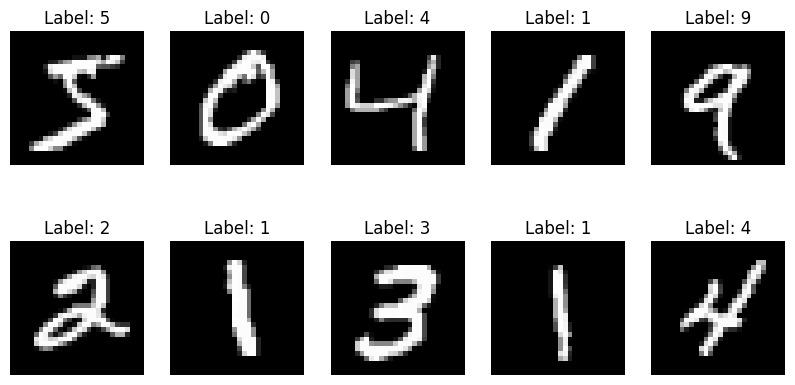

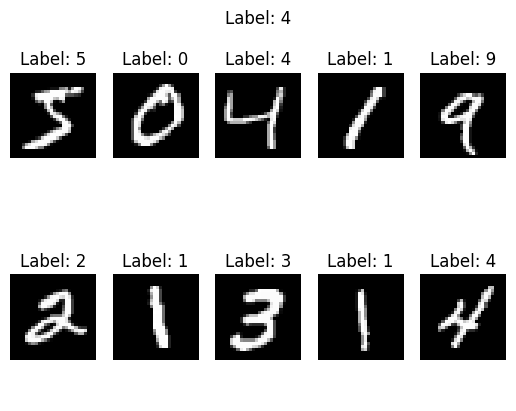

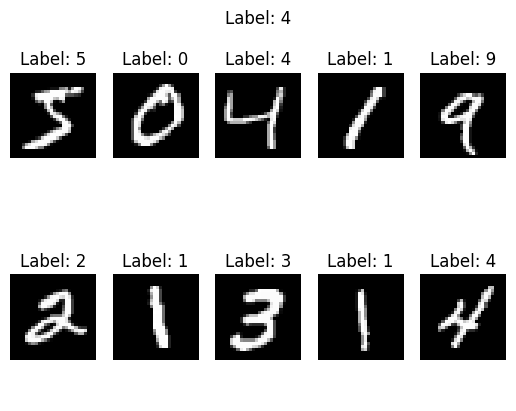

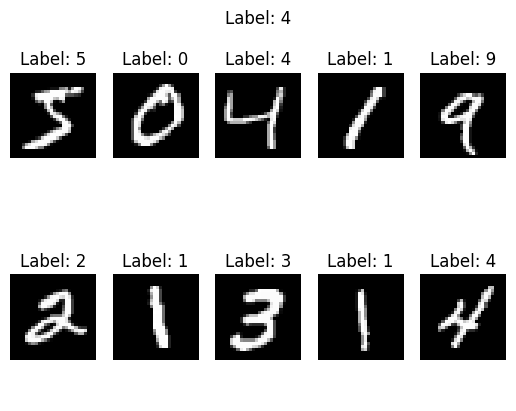

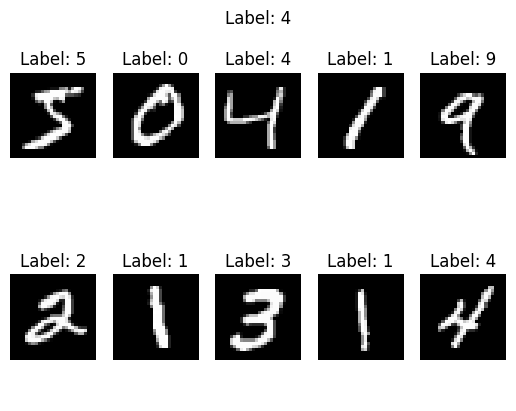

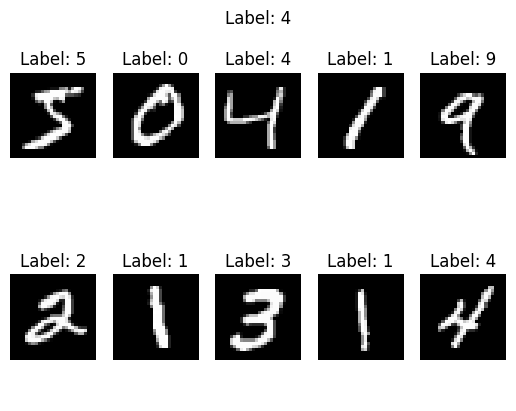

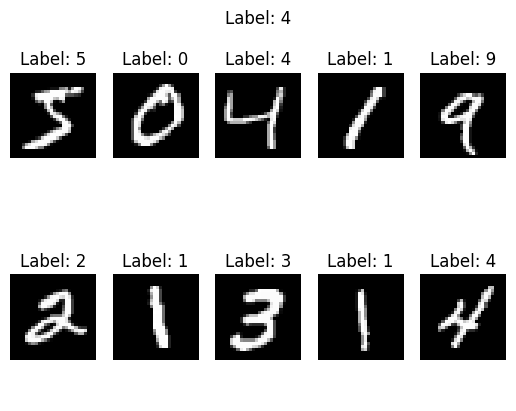

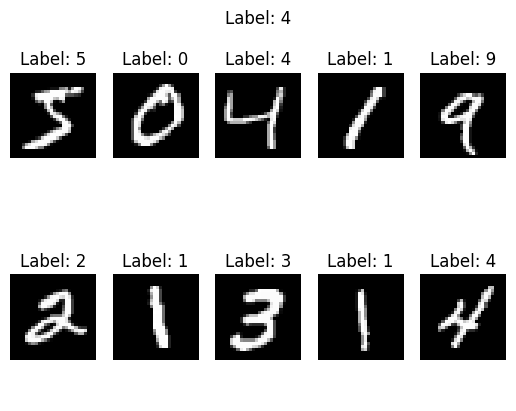

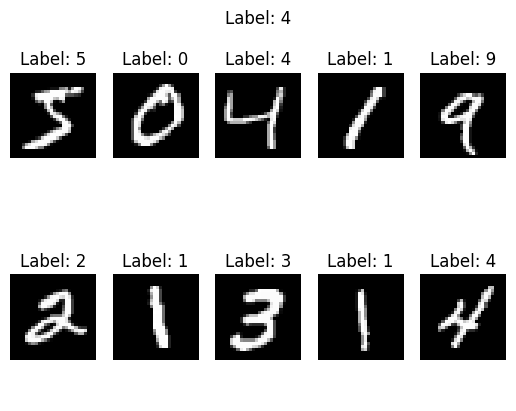

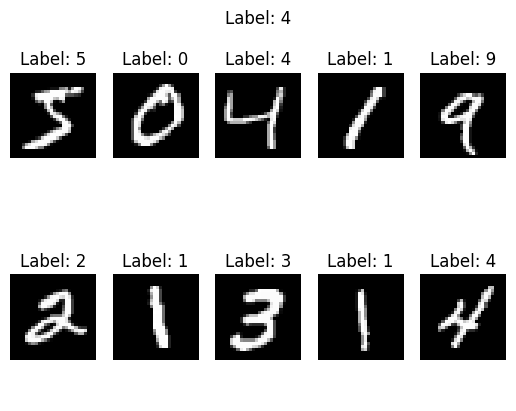

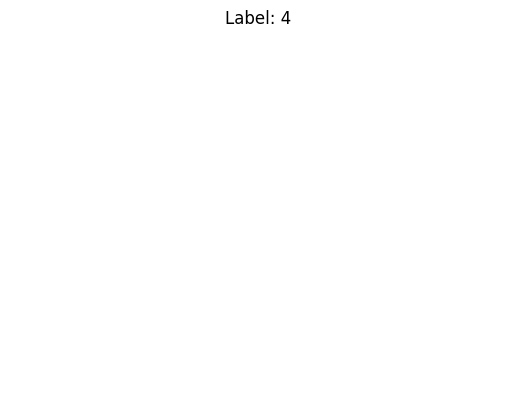

In [6]:
plt.figure(figsize=(10,5))

for i in range(10):

    for i in range(10):
        plt.subplot(2,5,i+1)
        img, label = x_train[i]
        plt.imshow(img.squeeze(), cmap='gray')
        plt.title(f"Label: {label}")
        plt.axis('off')

    plt.show()
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.show()

In [7]:
from torch.utils.data import Dataset, DataLoader
loaders={
    'train' : DataLoader(x_train, batch_size=100, shuffle=True,num_workers=1),
    'test' : DataLoader(x_test, batch_size=100, shuffle=True,num_workers=1)
}

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision

In [15]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, )
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2_dropout = nn.Dropout2d()
        self.fc1 = nn.Linear(1600,50)
        self.fc2 = nn.Linear(50, 10)
    
    def forward(self, x):
        x=F.relu(F.max_pool2d(self.conv1(x),2))
        x=F.relu(F.max_pool2d(self.conv2_dropout(self.conv2(x)),2))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x=F.dropout(x, training=self.training)
        x = self.fc2(x)
        return x

model = CNN()
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()
print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2_dropout): Dropout2d(p=0.5, inplace=False)
  (fc1): Linear(in_features=1600, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
)


In [16]:
def train(epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(loaders['train']):
        data,target = data, target
        optimizer.zero_grad()
        output = model(data)
        loss = loss_fn(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(loaders["train"].dataset)} ({100. * batch_idx / len(loaders["train"]):.0f}%)]\tLoss: {loss.item():.6f}')


def test():
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in loaders['test']:
            data, target = data, target
            output = model(data)
            test_loss += loss_fn(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(loaders['test'].dataset)
    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(loaders["test"].dataset)} ({100. * correct / len(loaders["test"].dataset):.0f}%)\n')

for epoch in range(1, 11):
    train(epoch)
    test()

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.304831
Train Epoch: 1 [10000/60000 (17%)]	Loss: 0.602272
Train Epoch: 1 [20000/60000 (33%)]	Loss: 0.461466
Train Epoch: 1 [30000/60000 (50%)]	Loss: 0.344002
Train Epoch: 1 [40000/60000 (67%)]	Loss: 0.185087
Train Epoch: 1 [50000/60000 (83%)]	Loss: 0.316691

Test set: Average loss: 0.0009, Accuracy: 9695/10000 (97%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.147940
Train Epoch: 2 [10000/60000 (17%)]	Loss: 0.185151
Train Epoch: 2 [20000/60000 (33%)]	Loss: 0.243146
Train Epoch: 2 [30000/60000 (50%)]	Loss: 0.278063
Train Epoch: 2 [40000/60000 (67%)]	Loss: 0.285763
Train Epoch: 2 [50000/60000 (83%)]	Loss: 0.396368

Test set: Average loss: 0.0006, Accuracy: 9800/10000 (98%)

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.147350
Train Epoch: 3 [10000/60000 (17%)]	Loss: 0.221345
Train Epoch: 3 [20000/60000 (33%)]	Loss: 0.155129
Train Epoch: 3 [30000/60000 (50%)]	Loss: 0.169158
Train Epoch: 3 [40000/60000 (67%)]	Loss: 0.220020
Train Epoch: 3 [50000/60000 (83%)]	Loss: 0.

In [17]:
#with lr=0.01
model_lr_0_01 = CNN()
optimizer_lr_0_01 = optim.Adam(model_lr_0_01.parameters(), lr=0.01)

accs_lr_0_01 = []
for epoch in range(1, 6):
    model_lr_0_01.train()
    for batch_idx, (data, target) in enumerate(loaders['train']):
        data,target = data, target
        optimizer_lr_0_01.zero_grad()
        output = model_lr_0_01(data)
        loss = loss_fn(output, target)
        loss.backward()
        optimizer_lr_0_01.step()

    #testing after each epoch
    model_lr_0_01.eval()
    correct = 0
    with torch.no_grad():
        for data, target in loaders['test']:
            data, target = data, target
            output = model_lr_0_01(data)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    acc = 100. * correct / len(loaders['test'].dataset)
    accs_lr_0_01.append(acc)
    print(f'Epoch {epoch}| lr=0.01 | Accuracy: {acc:.2f}%')

Epoch 1| lr=0.01 | Accuracy: 97.17%
Epoch 2| lr=0.01 | Accuracy: 97.44%
Epoch 3| lr=0.01 | Accuracy: 97.95%
Epoch 4| lr=0.01 | Accuracy: 98.07%
Epoch 5| lr=0.01 | Accuracy: 98.25%


In [24]:
#testing with lr=0.001
model_lr_0_001 = CNN()
optimizer_lr_0_001 = optim.Adam(model_lr_0_001.parameters(), lr=0.001)

accs_lr_0_001 = []
for epoch in range(1, 6):
    model_lr_0_001.train()
    for batch_idx, (data, target) in enumerate(loaders['train']):
        data,target = data, target
        optimizer_lr_0_001.zero_grad()
        output = model_lr_0_001(data)
        loss = loss_fn(output, target)
        loss.backward()
        optimizer_lr_0_001.step()

    #testing after each epoch
    model_lr_0_001.eval()
    correct = 0
    with torch.no_grad():
        for data, target in loaders['test']:
            data, target = data, target
            output = model_lr_0_001(data)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    acc = 100. * correct / len(loaders['test'].dataset)
    accs_lr_0_001.append(acc)
    print(f'Epoch {epoch}| lr=0.001 | Accuracy: {acc:.2f}%')

Epoch 1| lr=0.001 | Accuracy: 97.08%
Epoch 2| lr=0.001 | Accuracy: 97.92%
Epoch 3| lr=0.001 | Accuracy: 98.31%
Epoch 4| lr=0.001 | Accuracy: 98.57%
Epoch 5| lr=0.001 | Accuracy: 98.70%


In [23]:
#testing with lr=0.0001
model_lr_0_0001 = CNN()
optimizer_lr_0_0001 = optim.Adam(model_lr_0_0001.parameters(), lr=0.0001)

accs_lr_0_0001 = []
for epoch in range(1, 6):
    model_lr_0_0001.train()
    for batch_idx, (data, target) in enumerate(loaders['train']):
        data,target = data, target
        optimizer_lr_0_0001.zero_grad()
        output = model_lr_0_0001(data)
        loss = loss_fn(output, target)
        loss.backward()
        optimizer_lr_0_0001.step()

    #testing after each epoch
    model_lr_0_0001.eval()
    correct = 0
    with torch.no_grad():
        for data, target in loaders['test']:
            data, target = data, target
            output = model_lr_0_0001(data)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    acc = 100. * correct / len(loaders['test'].dataset)
    accs_lr_0_0001.append(acc)
    print(f'Epoch {epoch}| lr=0.0001 | Accuracy: {acc:.2f}%')

Epoch 1| lr=0.0001 | Accuracy: 91.46%
Epoch 2| lr=0.0001 | Accuracy: 94.47%
Epoch 3| lr=0.0001 | Accuracy: 95.47%
Epoch 4| lr=0.0001 | Accuracy: 96.17%
Epoch 5| lr=0.0001 | Accuracy: 96.71%


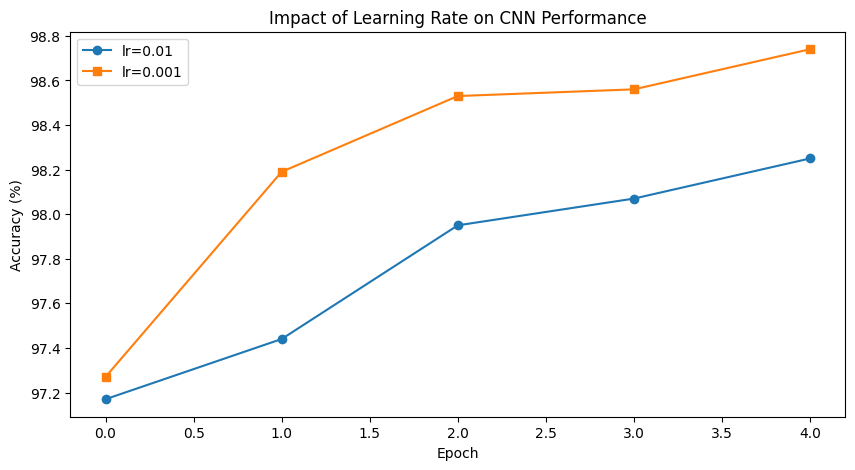

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(accs_lr_0_01, label='lr=0.01' , marker='o')
plt.plot(accs_lr_0_0001, label='lr=0.0001' , marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Impact of Learning Rate on CNN Performance')
plt.legend()
plt.savefig("plots/learning_rate_comparison.png", dpi=300, bbox_inches='tight')
plt.show()